# Sensitivity of the cell voltage to the undetermined parameters — dynamic model (with auxiliary system)

This notebook measures **how sensitive the cell voltage is to each undetermined physical
parameter, and how that sensitivity changes along the polarization curve** (from low to high
current), for the **1-D dual-scale dynamic model** `PEMFC` (`model/model.py`) run with the
**balance-of-plant / auxiliary system enabled** (`aux_system = True`, i.e. the air compressor,
humidifier injection and manifolds are integrated, not fixed).

### Normalized sensitivity coefficient

Each parameter $A$ is perturbed by a set of relative amounts $\Delta A_k/A$ around its nominal
value (here $\pm 10\%$ and $\pm 20\%$, so $k = 1\ldots 4$), everything else held fixed. For a
model output $R$ (a voltage or a loss), the sensitivity is the mean magnitude of the
relative-output / relative-input ratio:

$$\chi \;=\; \frac{1}{4}\sum_{k=1}^{4}\left|\frac{\Delta R_k / R}{\Delta A_k / A}\right|$$

$\chi$ is dimensionless: $\chi = 1$ means a 1 % parameter change gives a 1 % output change.
A parameter is called **sensitive** when $\chi > 0.05$. We also keep the *signed* version
(dropping the absolute value) to record the **direction** of influence.

### What is computed here

- $\chi$ resolved at **every current point** of the polarization curve.
- The output decomposed as $U_{cell} = OCV - \eta_{act} - \eta_{conc} - \eta_{ohm}$, so each
  loss channel gets its own sensitivity map.
- Signed sensitivities (direction of influence).
- Collinearity of the per-parameter sensitivity profiles (which parameters are
  interchangeable in a fit, and therefore not separately identifiable).
- Full parameter-range polarization families.


### Imports

In [1]:
import sys
import time
from copy import deepcopy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.integrate import solve_ivp
warnings.filterwarnings("ignore")

### Locate the project root and import the model

The project root is found by walking up from the notebook until the folder that holds
`config/initialize.py` and `model/model.py` is reached, so the notebook works regardless of
where it sits in the tree.

In [2]:
def find_project_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "initialize.py").exists() and (p / "model" / "model.py").exists():
            return p
    raise FileNotFoundError("project root not found (needs config/initialize.py and model/model.py)")

project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings   import solver_variable_names, solver_flux_names
from config.initialize import parameters, operating_inputs, init_x_for
from model.model       import PEMFC
from model.kinetic_eq  import Ucell, Rproton, eta_ccl, fdrop
from model.coefficients import n_cell
from modules.signals   import generate_polarization_load
print("project root:", project_root)

project root: D:\MFC2024


### Operating condition and current grid

Fixed operating point for the whole study: **$T_{fc} = 333.15$ K (60 °C)** and
**cathode relative humidity $RH_c = 0.5$**. Anode is dry ($RH_a = 0$, pure H₂), and the
supply pressure is set to 1.5 bar on both sides (a mid value of the test campaign). The
current is applied as a **slow staircase** so the compressor and manifolds track the load
without starving the cathode — this is the natural way to sweep a cell that has its
auxiliary system in the loop. The steady voltage is read at the end of each plateau, giving
one point of the polarization curve per current level.

In [3]:
T_FC     = 333.15          # K   (60 degC)
RHC      = 0.5             # cathode relative humidity
P_SUPPLY = 1.5e5          # Pa  (anode = cathode)

I_MAX   = 45.0            # A     top of the staircase
N_STEPS = 8               # number of current plateaus (= number of polarization points)
T_STEP  = 8.0             # s     plateau duration (compressor tau ~ 1 s, so this settles)
MAX_STEP = 2.0           # s     solver max internal step

Aact = parameters["Aact"]
i_levels = np.linspace(I_MAX / N_STEPS, I_MAX, N_STEPS) / Aact   # A m-2
i_points = i_levels / 1e4                                        # A cm-2
IDX_LOW, IDX_MID, IDX_HIGH = 1, 4, 7                             # 0.36, 0.91, 1.45 A cm-2
print("current points [A cm-2]:", np.round(i_points, 3))

current points [A cm-2]: [0.181 0.363 0.544 0.726 0.907 1.089 1.27  1.452]


### Suitable nominal values for the undetermined parameters

The values in `config/initialize.py` were tuned for the static model and drive the dynamic
model into oxygen starvation above ~0.5 A cm⁻² at this condition (the GDL there is thick and
strongly compressed). For a sensitivity study we need a **physically reasonable set that
produces a full, stable polarization curve**, so the values below are chosen accordingly:
an open, thinner GDL for healthy O₂ transport, a moderate exchange-current density, and
mid-range ohmic / two-phase values. The `lo`/`hi` columns are plausible physical bounds used
later for the full-range sweeps; the OAT itself only uses ±10 %/±20 % around the nominal.

Groups: **kinetics** (charge transfer), **ohmic** (proton/electron conduction),
**mass transport** (gas + water through the porous media), **two-phase** (liquid-water
voltage-drop switch), **crossover** (gas permeation through the membrane).

`C_scl` (double-layer capacitance) is excluded: it only scales the $d\eta_c/dt$ transient,
which this model evaluates algebraically, so it does not affect the steady voltage.

In [4]:
# name: (nominal, lo, hi, group)
PARAM_SPACE = {
    "OCV":         (0.95,   0.90,  1.00,  "kinetics"),
    "i0_c_ref":    (0.5,    0.05,  5.0,   "kinetics"),
    "kappa_c":     (1.0,    0.5,   3.0,   "kinetics"),
    "epsilon_mc":  (0.30,   0.15,  0.5,   "ohmic"),
    "tau":         (1.5,    1.0,   4.0,   "ohmic"),
    "Re":          (2e-6,   1e-7,  1e-5,  "ohmic"),
    "epsilon_gdl": (0.70,   0.55,  0.80,  "mass transport"),
    "epsilon_c":   (0.15,   0.10,  0.30,  "mass transport"),
    "epsilon_cl":  (0.30,   0.15,  0.45,  "mass transport"),
    "Hgdl":        (2e-4,   1.5e-4, 3e-4, "mass transport"),
    "Hcl":         (1e-5,   5e-6,  2e-5,  "mass transport"),
    "e":           (3.0,    2.0,   5.0,   "mass transport"),
    "a_slim":      (0.05,   0.01,  0.3,   "two-phase"),
    "b_slim":      (0.30,   0.10,  0.9,   "two-phase"),
    "a_switch":    (0.20,   0.05,  0.5,   "two-phase"),
    "kappa_co":    (37.2,   10.0,  80.0,  "crossover"),
}
PARAM_NAMES = list(PARAM_SPACE)

# Nominal parameter dict used for every simulation.
params_nom = deepcopy(parameters)
params_nom["aux_system"] = True
for name, (nom, *_ ) in PARAM_SPACE.items():
    params_nom[name] = nom

param_df = pd.DataFrame(
    {n: {"nominal": v[0], "lo": v[1], "hi": v[2], "group": v[3]} for n, v in PARAM_SPACE.items()}
).T
print(param_df.to_string(float_format=lambda v: f"{v:.4g}"))

            nominal      lo     hi           group
OCV            0.95     0.9      1        kinetics
i0_c_ref        0.5    0.05      5        kinetics
kappa_c           1     0.5      3        kinetics
epsilon_mc      0.3    0.15    0.5           ohmic
tau             1.5       1      4           ohmic
Re            2e-06   1e-07  1e-05           ohmic
epsilon_gdl     0.7    0.55    0.8  mass transport
epsilon_c      0.15     0.1    0.3  mass transport
epsilon_cl      0.3    0.15   0.45  mass transport
Hgdl         0.0002 0.00015 0.0003  mass transport
Hcl           1e-05   5e-06  2e-05  mass transport
e                 3       2      5  mass transport
a_slim         0.05    0.01    0.3       two-phase
b_slim          0.3     0.1    0.9       two-phase
a_switch        0.2    0.05    0.5       two-phase
kappa_co       37.2      10     80       crossover


### The polarization-curve simulator

`polarization_curve(params)` runs one staircase sweep with the auxiliary system on and returns
the steady cell voltage and its loss decomposition at each current level:

$$U_{cell} = OCV - \eta_{ohm} - \eta_{act} - \eta_{conc},\qquad
\eta_{ohm} = i\,\big(\textstyle\sum R_{mem} + R_{ccl} + R_{acl} + R_e\big)$$

$\eta_{act}$ and $\eta_{conc}$ are the activation and concentration parts of the cathode
overpotential, split by the flooding factor $f_{drop}$ exactly as the model does internally.
The solver tries BDF first (fast) and falls back to LSODA (robust) if BDF hits the known
dual-scale NaN; a level that fails on both is returned as NaN.

In [ ]:
OUTPUTS = ["Ucell", "eta_act", "eta_conc", "eta_ohm"]

def _robust_solve(model, x0, t_end):
    """Integrate to t_end; BDF first, LSODA fallback. Returns sol or None."""
    for method, kw in (("BDF", dict(max_step=MAX_STEP)),
                       ("LSODA", dict(max_step=MAX_STEP))):
        try:
            sol = solve_ivp(model.dxdt, (0, t_end), x0, method=method, **kw)
        except Exception:
            continue
        if sol.success and np.all(np.isfinite(sol.y[:, -1])):
            return sol
    return None

def _losses(last, op, params, i_dens):
    """Voltage and loss decomposition at one steady state."""
    Rmem, Rccl, Racl = Rproton(last, params, op)
    eta_ohm = i_dens * (sum(Rmem) + Rccl + params["Re"])
    eta_c   = eta_ccl(last, op, params)          # total cathode overpotential
    f_drop  = fdrop(last, op, params)
    if f_drop >= 1.0:
        eta_act, eta_conc = eta_c, 0.0
    else:
        eta_conc = eta_c * (1.0 - f_drop) / f_drop
        eta_act  = eta_c - eta_conc
    U = params["OCV"] - eta_ohm - eta_c
    return U, eta_act, eta_conc, eta_ohm

def polarization_curve(params):
    """Staircase sweep with aux system on -> dict of arrays over i_points."""
    p = deepcopy(params); p["aux_system"] = True
    op = deepcopy(operating_inputs)
    op["Tfc"], op["Phi_a_des"], op["Phi_c_des"] = T_FC, 0.0, RHC
    op["Pa_des"], op["Pc_des"] = P_SUPPLY, P_SUPPLY
    op["current_density"] = generate_polarization_load(I_MAX / p["Aact"], N_STEPS, T_STEP)

    model = PEMFC(param=p, operating_inputs=op,
                  variable_names=solver_variable_names, flux_names=solver_flux_names)
    x0  = init_x_for("dual-scale", op, model.parameters)
    sol = _robust_solve(model, x0, N_STEPS * T_STEP)

    out = {k: np.full(N_STEPS, np.nan) for k in OUTPUTS}
    if sol is None:
        return out
    for k in range(N_STEPS):
        j = np.searchsorted(sol.t, (k + 1) * T_STEP - 1e-3) - 1
        last = {key: sol.y[idx, j] for idx, key in enumerate(model.variable_names)}
        op_k = deepcopy(op); op_k["current_density"] = lambda t, _i=i_levels[k]: _i
        try:
            U, ea, ec, eo = _losses(last, op_k, p, i_levels[k])
        except Exception:
            continue
        if np.isfinite(U):
            out["Ucell"][k], out["eta_act"][k], out["eta_conc"][k], out["eta_ohm"][k] = U, ea, ec, eo
    return out

### Baseline polarization curve

Run the nominal set once and check the curve is complete and physically shaped (a kinetic
knee at low current, a roughly linear ohmic region, and a mass-transport roll-off at high
current), and that the losses add up to the terminal voltage.

baseline curve solved in 9.2 s


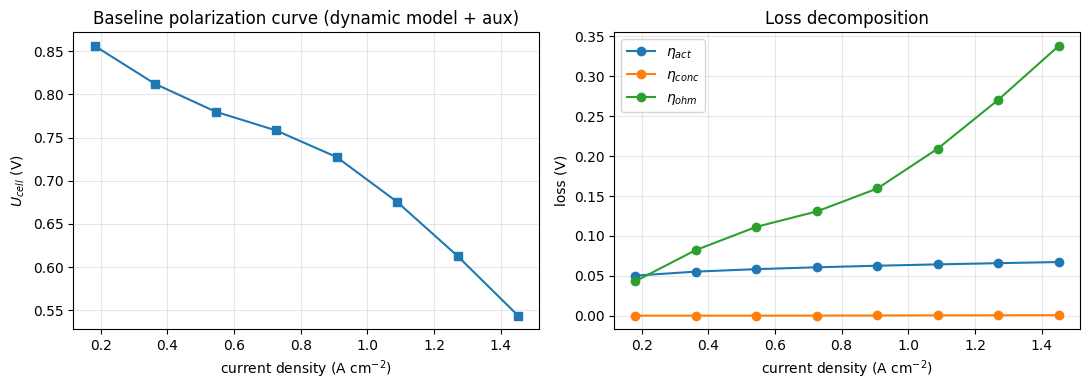

check  OCV - sum(losses) - Ucell  (should be ~0): 1.1102230246251565e-16


In [6]:
t0 = time.time()
base = polarization_curve(params_nom)
print(f"baseline curve solved in {time.time()-t0:.1f} s")

fig, (axU, axL) = plt.subplots(1, 2, figsize=(11, 4))
axU.plot(i_points, base["Ucell"], "s-", color="tab:blue")
axU.set_xlabel(r"current density (A cm$^{-2}$)"); axU.set_ylabel(r"$U_{cell}$ (V)")
axU.set_title("Baseline polarization curve (dynamic model + aux)"); axU.grid(alpha=0.3)

axL.plot(i_points, base["eta_act"],  "o-", label=r"$\eta_{act}$")
axL.plot(i_points, base["eta_conc"], "o-", label=r"$\eta_{conc}$")
axL.plot(i_points, base["eta_ohm"],  "o-", label=r"$\eta_{ohm}$")
axL.set_xlabel(r"current density (A cm$^{-2}$)"); axL.set_ylabel("loss (V)")
axL.set_title("Loss decomposition"); axL.grid(alpha=0.3); axL.legend()
plt.tight_layout(); plt.show()

print("check  OCV - sum(losses) - Ucell  (should be ~0):",
      np.nanmax(np.abs(params_nom["OCV"] - base["eta_act"] - base["eta_conc"]
                       - base["eta_ohm"] - base["Ucell"])))

### OAT engine

For each parameter, re-solve the whole curve at the four perturbation levels $\pm10\%,\pm20\%$.
From the relative output changes we form:

- `delta[out][p, k, i]` — relative change of output *out* for parameter *p*, level *k*, current *i*;
- `chi[out][p, i]` — the normalized sensitivity coefficient defined above;
- `signed[out][p, i]` — same but keeping the sign (direction of influence).

A perturbation whose curve failed contributes NaN and is simply skipped in the averages.

In [7]:
REL_LEVELS = np.array([-0.20, -0.10, 0.10, 0.20])

def oat_sweep(base_params):
    base_out = polarization_curve(base_params)
    n_p, n_l, n_i = len(PARAM_NAMES), len(REL_LEVELS), N_STEPS
    delta = {o: np.full((n_p, n_l, n_i), np.nan) for o in OUTPUTS}
    for ip, name in enumerate(PARAM_NAMES):
        nom = PARAM_SPACE[name][0]
        for il, rel in enumerate(REL_LEVELS):
            p = deepcopy(base_params); p[name] = nom * (1 + rel)
            res = polarization_curve(p)
            for o in OUTPUTS:
                delta[o][ip, il] = (res[o] - base_out[o]) / base_out[o]
    chi    = {o: np.nanmean(np.abs(delta[o]) / np.abs(REL_LEVELS)[None, :, None], axis=1) for o in OUTPUTS}
    signed = {o: np.nanmean(delta[o] / REL_LEVELS[None, :, None], axis=1) for o in OUTPUTS}
    return base_out, delta, chi, signed

### Run the OAT

One baseline plus 16 parameters × 4 levels = 65 staircase integrations. Progress is printed
per parameter.

In [8]:
t0 = time.time()
print(f"running OAT: {1 + len(PARAM_NAMES)*len(REL_LEVELS)} curves ...")
base, delta, chi, signed = oat_sweep(params_nom)
n_nan = int(np.isnan(delta["Ucell"]).sum())
print(f"done in {time.time()-t0:.0f} s   ({n_nan} NaN entries out of {delta['Ucell'].size} in Ucell deltas)")

running OAT: 65 curves ...


done in 576 s   (40 NaN entries out of 512 in Ucell deltas)


### Sensitivity map of the cell voltage across the current range

Heatmap of $\chi_{U_{cell}}$, one row per parameter (sorted by peak sensitivity), one column
per current point. Bold numbers exceed the 0.05 sensitivity threshold. `OCV` enters the
voltage additively, so its $\chi \approx OCV/U_{cell} \gtrsim 1$ and saturates the color
scale by design.

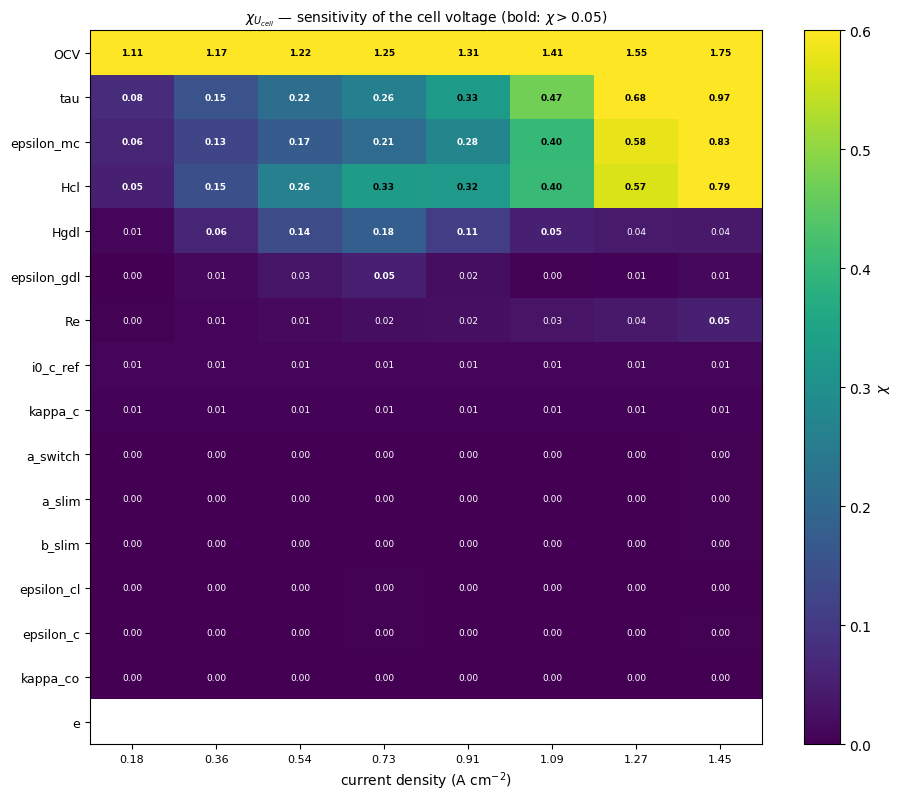

In [9]:
def plot_chi_heatmap(chi_mat, names, title, vmax=0.6, thr=0.05):
    order = np.argsort(-np.nanmax(chi_mat, axis=1))
    mat = chi_mat[order]; nms = [names[o] for o in order]
    fig, ax = plt.subplots(figsize=(9.5, 0.42*len(nms) + 1.4))
    im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(i_points))); ax.set_xticklabels([f"{v:.2f}" for v in i_points], fontsize=8)
    ax.set_yticks(range(len(nms))); ax.set_yticklabels(nms, fontsize=9)
    ax.set_xlabel(r"current density (A cm$^{-2}$)")
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            v = mat[r, c]
            if np.isfinite(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                        color="white" if v < 0.5*vmax else "black",
                        fontweight="bold" if v > thr else "normal")
    ax.set_title(title, fontsize=10); fig.colorbar(im, ax=ax, label=r"$\chi$")
    plt.tight_layout(); plt.show()
    return nms

_ = plot_chi_heatmap(chi["Ucell"], PARAM_NAMES,
                     r"$\chi_{U_{cell}}$ — sensitivity of the cell voltage (bold: $\chi>0.05$)")

### How the sensitive parameters evolve with current

Line plot (log scale) of $\chi_{U_{cell}}$ versus current for every parameter that crosses
the 0.05 threshold anywhere on the curve. This shows whether a parameter matters mostly at
low current (kinetics), high current (transport / flooding), or uniformly (offset / ohmic).

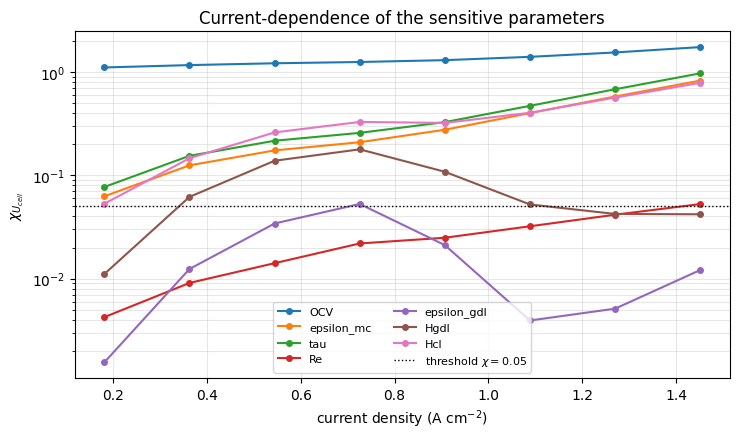

sensitive somewhere on the curve: ['OCV', 'epsilon_mc', 'tau', 'Re', 'epsilon_gdl', 'Hgdl', 'Hcl']


In [10]:
sens_any = [n for ip, n in enumerate(PARAM_NAMES) if np.nanmax(chi["Ucell"][ip]) > 0.05]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for n in sens_any:
    ip = PARAM_NAMES.index(n)
    ax.plot(i_points, chi["Ucell"][ip], "o-", markersize=4, label=n)
ax.axhline(0.05, color="k", ls=":", lw=1, label=r"threshold $\chi=0.05$")
ax.set_yscale("log"); ax.set_xlabel(r"current density (A cm$^{-2}$)"); ax.set_ylabel(r"$\chi_{U_{cell}}$")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8, ncol=2)
ax.set_title("Current-dependence of the sensitive parameters")
plt.tight_layout(); plt.show()
print("sensitive somewhere on the curve:", sens_any)

### Voltage change in millivolts (tornado)

The same information in engineering units: the change in cell voltage (mV) when each
parameter is moved −20 % (blue) and +20 % (red), at a low, medium and high current point.

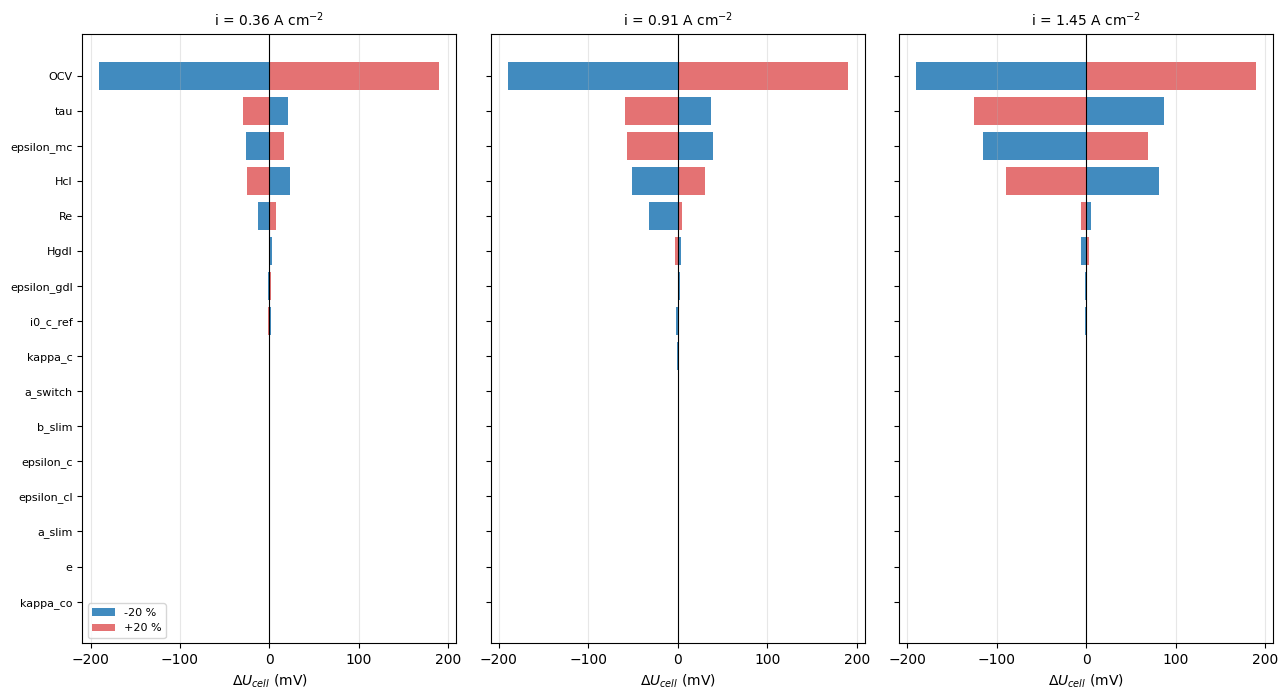

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 0.35*len(PARAM_NAMES) + 1.5), sharey=True)
for ax, idx in zip(axes, [IDX_LOW, IDX_MID, IDX_HIGH]):
    dU_minus = delta["Ucell"][:, 0, idx] * base["Ucell"][idx] * 1e3
    dU_plus  = delta["Ucell"][:, 3, idx] * base["Ucell"][idx] * 1e3
    span = np.maximum(np.abs(np.nan_to_num(dU_minus)), np.abs(np.nan_to_num(dU_plus)))
    order = np.argsort(span); y = np.arange(len(PARAM_NAMES))
    ax.barh(y, dU_minus[order], color="tab:blue", alpha=0.85, label="-20 %")
    ax.barh(y, dU_plus[order],  color="tab:red",  alpha=0.65, label="+20 %")
    ax.set_yticks(y); ax.set_yticklabels([PARAM_NAMES[o] for o in order], fontsize=8)
    ax.axvline(0, color="k", lw=0.8); ax.grid(alpha=0.3, axis="x")
    ax.set_title(f"i = {i_points[idx]:.2f} A cm$^{{-2}}$", fontsize=10)
    ax.set_xlabel(r"$\Delta U_{cell}$ (mV)")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Which loss channel does each parameter act through?

$U_{cell} = OCV - \eta_{act} - \eta_{conc} - \eta_{ohm}$. Separating the sensitivity of each
loss shows the *mechanism*: kinetic parameters act on $\eta_{act}$, conduction parameters on
$\eta_{ohm}$, and gas-/water-transport and two-phase parameters on $\eta_{conc}$ (which is
only non-zero once liquid water starts to matter at high current).

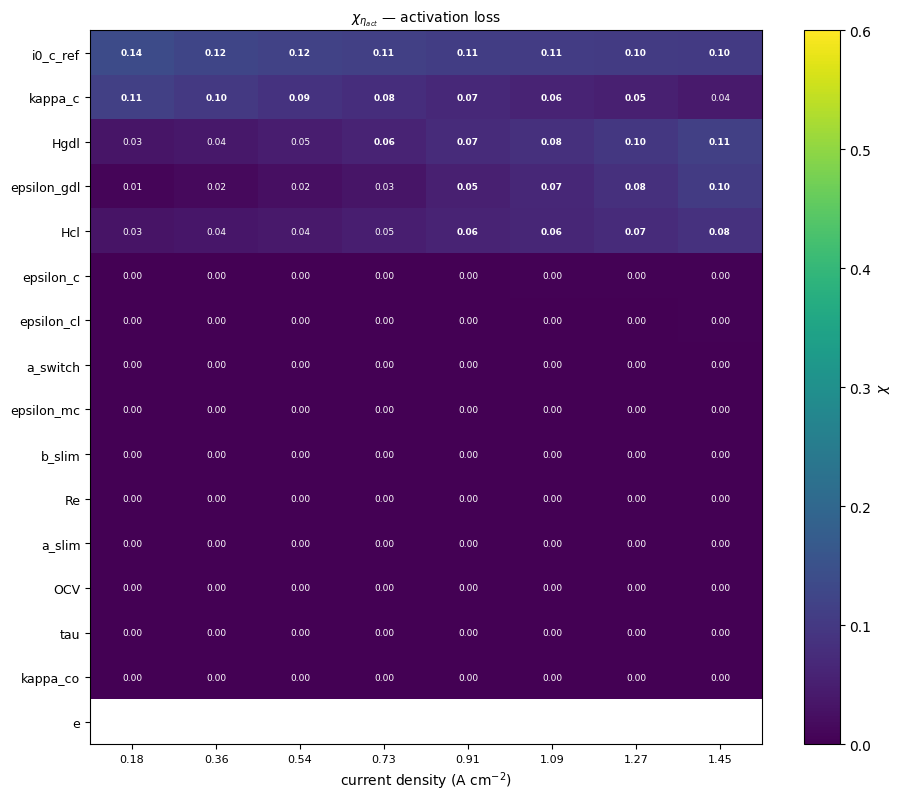

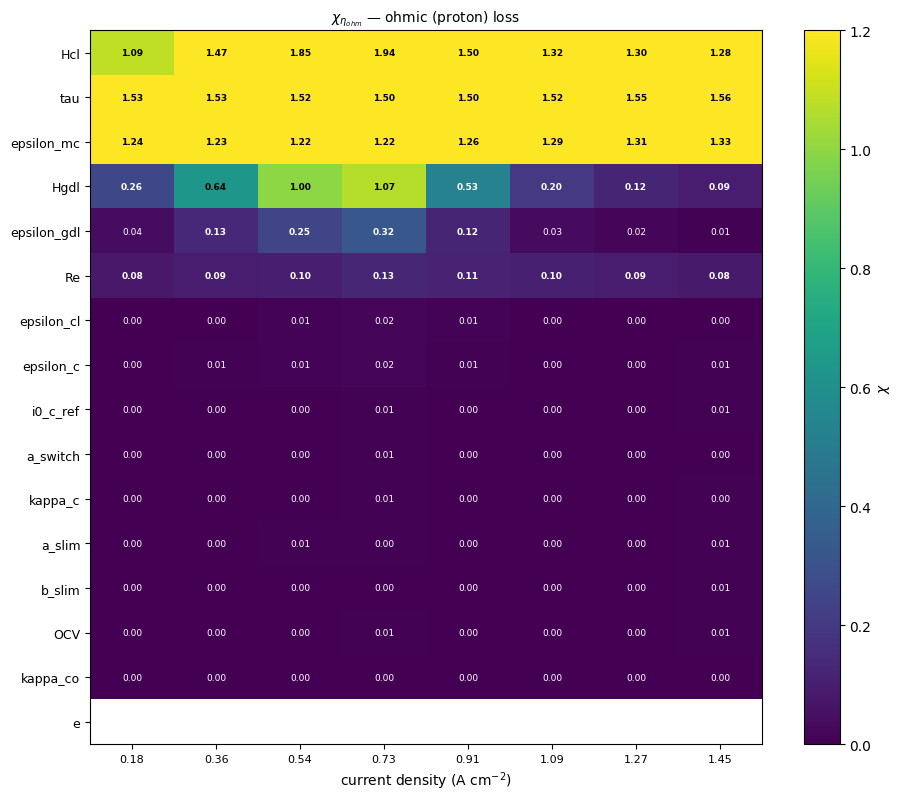

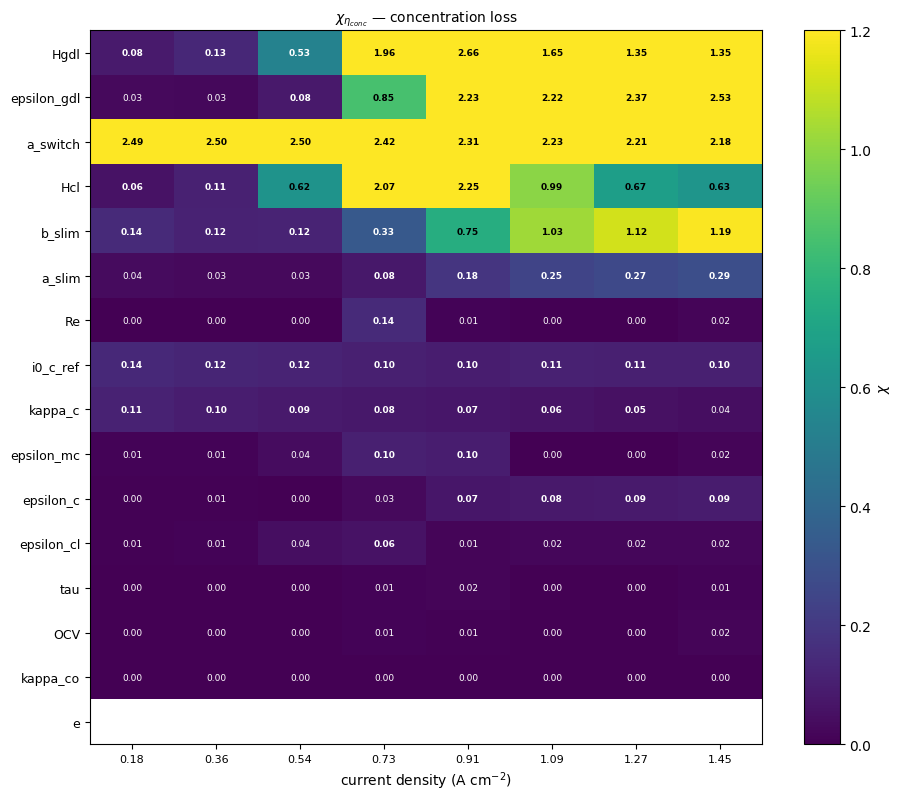

['Hgdl',
 'epsilon_gdl',
 'a_switch',
 'Hcl',
 'b_slim',
 'a_slim',
 'Re',
 'i0_c_ref',
 'kappa_c',
 'epsilon_mc',
 'epsilon_c',
 'epsilon_cl',
 'tau',
 'OCV',
 'kappa_co',
 'e']

In [12]:
plot_chi_heatmap(chi["eta_act"],  PARAM_NAMES, r"$\chi_{\eta_{act}}$ — activation loss",     vmax=0.6)
plot_chi_heatmap(chi["eta_ohm"],  PARAM_NAMES, r"$\chi_{\eta_{ohm}}$ — ohmic (proton) loss",  vmax=1.2)
plot_chi_heatmap(chi["eta_conc"], PARAM_NAMES, r"$\chi_{\eta_{conc}}$ — concentration loss", vmax=1.2)

### Sensitive-parameter sets at low vs high current

Tabulated sensitive parameters (χ > 0.05, ranked) for each output at a low and a high current
point, and the overlap of the cell-voltage sensitive set between the two currents — this is
what tells you the order in which parameters should be identified.

In [13]:
THR = 0.05
rows = []
for label, idx in [(f"low  ({i_points[IDX_LOW]:.2f})", IDX_LOW),
                   (f"high ({i_points[IDX_HIGH]:.2f})", IDX_HIGH)]:
    for o, olab in [("Ucell","U_cell"),("eta_act","eta_act"),("eta_conc","eta_conc"),("eta_ohm","eta_ohm")]:
        sens = [n for ip, n in enumerate(PARAM_NAMES) if chi[o][ip, idx] > THR]
        sens.sort(key=lambda n: -chi[o][PARAM_NAMES.index(n), idx])
        rows.append({"current (A/cm2)": label, "output": olab,
                     "sensitive parameters (ranked)": ", ".join(sens) if sens else "none"})
print(pd.DataFrame(rows).to_string(index=False))

set_lo = {n for ip, n in enumerate(PARAM_NAMES) if chi["Ucell"][ip, IDX_LOW]  > THR}
set_hi = {n for ip, n in enumerate(PARAM_NAMES) if chi["Ucell"][ip, IDX_HIGH] > THR}
print("\nU_cell sensitive at BOTH currents:", sorted(set_lo & set_hi))
print("U_cell sensitive only at high     :", sorted(set_hi - set_lo))
print("U_cell sensitive only at low      :", sorted(set_lo - set_hi))

current (A/cm2)   output                                         sensitive parameters (ranked)
    low  (0.36)   U_cell                                       OCV, tau, Hcl, epsilon_mc, Hgdl
    low  (0.36)  eta_act                                                     i0_c_ref, kappa_c
    low  (0.36) eta_conc                        a_switch, Hgdl, i0_c_ref, b_slim, Hcl, kappa_c
    low  (0.36)  eta_ohm                           tau, Hcl, epsilon_mc, Hgdl, epsilon_gdl, Re
    high (1.45)   U_cell                                         OCV, tau, epsilon_mc, Hcl, Re
    high (1.45)  eta_act                                      Hgdl, epsilon_gdl, i0_c_ref, Hcl
    high (1.45) eta_conc epsilon_gdl, a_switch, Hgdl, b_slim, Hcl, a_slim, i0_c_ref, epsilon_c
    high (1.45)  eta_ohm                                        tau, epsilon_mc, Hcl, Hgdl, Re

U_cell sensitive at BOTH currents: ['Hcl', 'OCV', 'epsilon_mc', 'tau']
U_cell sensitive only at high     : ['Re']
U_cell sensitive only at low  

### Direction of influence

Signed sensitivity at low and high current: a `+` means increasing the parameter **raises**
the cell voltage, a `-` means it lowers it, `0` means negligible.

In [14]:
def arrow(v, tol=5e-3):
    if not np.isfinite(v): return "nan"
    return "+" if v > tol else ("-" if v < -tol else "0")

dir_df = pd.DataFrame({
    "eps @ low":  signed["Ucell"][:, IDX_LOW],
    "dir @ low":  [arrow(v) for v in signed["Ucell"][:, IDX_LOW]],
    "eps @ high": signed["Ucell"][:, IDX_HIGH],
    "dir @ high": [arrow(v) for v in signed["Ucell"][:, IDX_HIGH]],
}, index=PARAM_NAMES).sort_values("eps @ high", key=lambda s: -s.abs())
print(dir_df.to_string(float_format=lambda v: f"{v:+.4f}"))

             eps @ low dir @ low  eps @ high dir @ high
OCV            +1.1696         +     +1.7474          +
tau            -0.1546         -     -0.9729          -
epsilon_mc     +0.1251         +     +0.8274          +
Hcl            -0.1466         -     -0.7875          -
Re             -0.0091         -     -0.0527          -
Hgdl           +0.0619         +     +0.0420          +
i0_c_ref       +0.0085         +     +0.0117          +
epsilon_gdl    -0.0124         -     +0.0113          +
kappa_c        +0.0067         +     +0.0056          +
a_switch       +0.0004         0     +0.0030          0
b_slim         +0.0002         0     +0.0018          0
epsilon_c      +0.0007         0     -0.0003          0
epsilon_cl     -0.0003         0     +0.0003          0
a_slim         +0.0001         0     -0.0000          0
kappa_co       +0.0000         0     +0.0000          0
e                  NaN       nan         NaN        nan


### Are any parameters interchangeable? — collinearity of sensitivity profiles

If two parameters shift the polarization curve in the *same shape*, a fit cannot tell them
apart — only their combination is identifiable. For each parameter its signed profile
$\varepsilon_U(i)$ over all current points is a vector; the matrix below is the absolute
cosine similarity between these vectors. Values near **1** mark (anti)parallel pairs that are
degenerate at this operating point; distinct shapes (well below 1) can be separated by fitting
several current regions together.

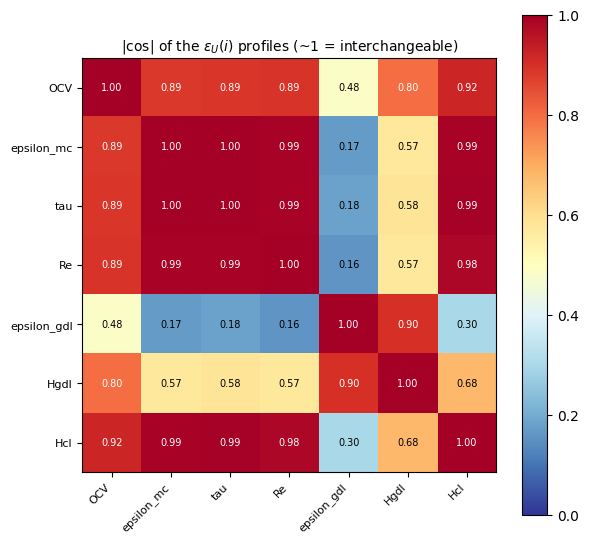

near-degenerate pairs (|cos| > 0.98):
  epsilon_mc   <-> tau           |cos| = 1.000
  epsilon_mc   <-> Re            |cos| = 0.991
  epsilon_mc   <-> Hcl           |cos| = 0.991
  tau          <-> Re            |cos| = 0.991
  tau          <-> Hcl           |cos| = 0.992
  Re           <-> Hcl           |cos| = 0.982


In [15]:
keep = [n for ip, n in enumerate(PARAM_NAMES) if np.nanmax(chi["Ucell"][ip]) > 0.02]
G = np.array([np.nan_to_num(signed["Ucell"][PARAM_NAMES.index(n)]) for n in keep])
norms = np.linalg.norm(G, axis=1, keepdims=True); norms[norms == 0] = 1
C = np.abs((G / norms) @ (G / norms).T)

fig, ax = plt.subplots(figsize=(0.6*len(keep) + 2, 0.6*len(keep) + 1.5))
im = ax.imshow(C, cmap="RdYlBu_r", vmin=0, vmax=1)
ax.set_xticks(range(len(keep))); ax.set_xticklabels(keep, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(keep))); ax.set_yticklabels(keep, fontsize=8)
for r in range(len(keep)):
    for c in range(len(keep)):
        ax.text(c, r, f"{C[r,c]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if C[r, c] > 0.75 else "black")
ax.set_title(r"$|\cos|$ of the $\varepsilon_U(i)$ profiles (~1 = interchangeable)", fontsize=10)
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

print("near-degenerate pairs (|cos| > 0.98):")
for a in range(len(keep)):
    for b in range(a+1, len(keep)):
        if C[a, b] > 0.98:
            print(f"  {keep[a]:12s} <-> {keep[b]:12s}  |cos| = {C[a, b]:.3f}")

### Full parameter-range polarization families

The OAT only probes ±20 % around the nominal, which can miss a parameter that is flat locally
but strong elsewhere in its range. Each panel sweeps one parameter across its full plausible
range (5 levels, everything else nominal); the black dashed line is the nominal curve.

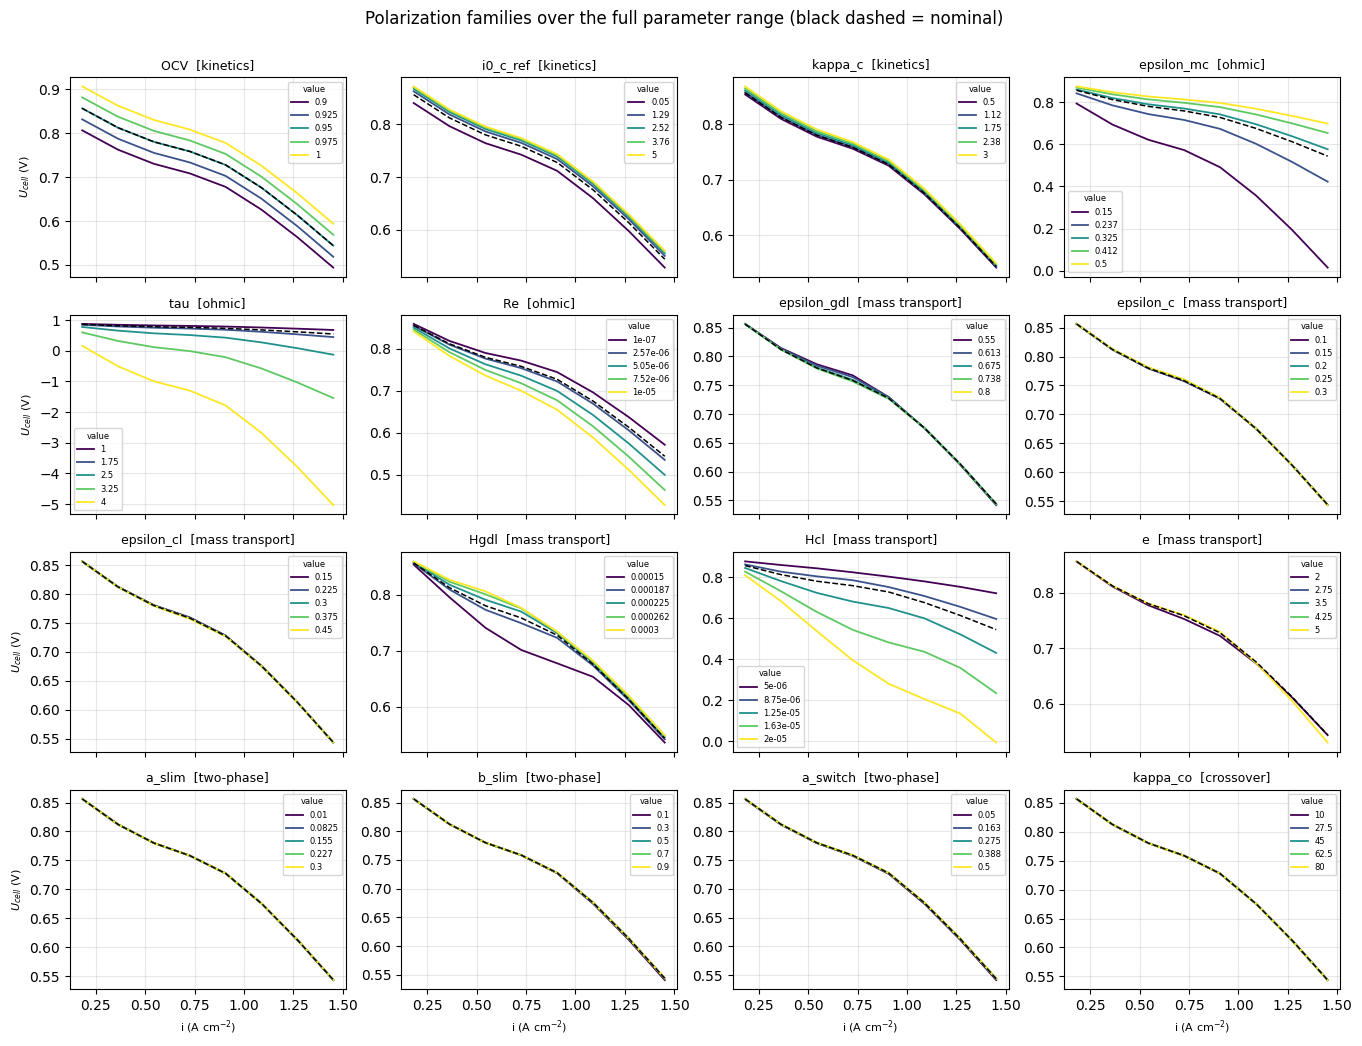

In [16]:
N_LEV = 5
ncols = 4; nrows = int(np.ceil(len(PARAM_NAMES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4*ncols, 2.6*nrows), sharex=True, squeeze=False)
cmap = plt.cm.viridis
for k, name in enumerate(PARAM_NAMES):
    ax = axes[k // ncols][k % ncols]
    nom, lo, hi, group = PARAM_SPACE[name]
    levels = np.linspace(lo, hi, N_LEV)
    for j, val in enumerate(levels):
        p = deepcopy(params_nom); p[name] = val
        res = polarization_curve(p)
        ax.plot(i_points, res["Ucell"], "-", color=cmap(j/(N_LEV-1)), lw=1.3, label=f"{val:.3g}")
    ax.plot(i_points, base["Ucell"], "k--", lw=1.1)
    ax.set_title(f"{name}  [{group}]", fontsize=9)
    ax.grid(alpha=0.3); ax.legend(fontsize=6, title="value", title_fontsize=6)
for k in range(len(PARAM_NAMES), nrows*ncols):
    axes[k // ncols][k % ncols].set_visible(False)
for ax in axes[-1]: ax.set_xlabel(r"i (A cm$^{-2}$)", fontsize=8)
for row in axes:   row[0].set_ylabel(r"$U_{cell}$ (V)", fontsize=8)
fig.suptitle("Polarization families over the full parameter range (black dashed = nominal)", y=1.001)
plt.tight_layout(); plt.show()

### Summary and automatic classification

Each parameter is tagged by where its influence concentrates and whether it is identifiable
from a polarization curve at all.

In [17]:
chi_lo, chi_hi = chi["Ucell"][:, IDX_LOW], chi["Ucell"][:, IDX_HIGH]
chi_mx = np.nanmax(chi["Ucell"], axis=1)

def classify(lo, hi, mx):
    if not np.isfinite(mx) or mx <= 0.05: return "insensitive (freeze)"
    if hi > 2*max(lo, 1e-12): return "high-current dominated"
    if lo > 2*max(hi, 1e-12): return "low-current dominated"
    return "uniform across current"

summary = pd.DataFrame({
    "group":      [PARAM_SPACE[n][3] for n in PARAM_NAMES],
    "chi @ low":  chi_lo,
    "chi @ high": chi_hi,
    "chi max":    chi_mx,
    "dir @ high": [arrow(v) for v in signed["Ucell"][:, IDX_HIGH]],
    "class":      [classify(l, h, m) for l, h, m in zip(chi_lo, chi_hi, chi_mx)],
}, index=PARAM_NAMES).sort_values("chi max", ascending=False)
print(summary.to_string(float_format=lambda v: f"{v:.3f}"))

                      group  chi @ low  chi @ high  chi max dir @ high                   class
OCV                kinetics      1.170       1.747    1.747          +  uniform across current
tau                   ohmic      0.155       0.973    0.973          -  high-current dominated
epsilon_mc            ohmic      0.125       0.827    0.827          +  high-current dominated
Hcl          mass transport      0.147       0.787    0.787          -  high-current dominated
Hgdl         mass transport      0.062       0.042    0.179          +  uniform across current
epsilon_gdl  mass transport      0.012       0.012    0.053          +  uniform across current
Re                    ohmic      0.009       0.053    0.053          -  high-current dominated
i0_c_ref           kinetics      0.008       0.012    0.012          +    insensitive (freeze)
kappa_c            kinetics      0.007       0.006    0.007          +    insensitive (freeze)
a_switch          two-phase      0.000       0.004

## Conclusions

*Dynamic model `PEMFC` with `aux_system = True`, at T = 333.15 K, RH_c = 0.5, 1.5 bar. χ is the normalized sensitivity coefficient; a parameter is "sensitive" when χ > 0.05.*

### 1. What moves the cell voltage, and where on the curve

Seven of the sixteen parameters are sensitive somewhere on the polarization curve. Their behaviour splits cleanly by current:

| parameter | χ @ 0.36 A cm⁻² | χ @ 1.45 A cm⁻² | dir | class | acts through |
|---|---|---|---|---|---|
| `OCV` | 1.17 | 1.75 | + | uniform | additive offset |
| `tau` | 0.155 | 0.973 | − | high-current | ohmic $R_{ccl}\propto\varepsilon_{mc}^{-\tau}$ |
| `epsilon_mc` | 0.125 | 0.827 | + | high-current | ohmic $R_{ccl}\propto\varepsilon_{mc}^{-\tau}$ |
| `Hcl` | 0.147 | 0.787 | − | high-current | CCL proton resistance + water |
| `Hgdl` | 0.062 | 0.042 (peak 0.18 mid) | + | uniform | O₂ diffusion path |
| `Re` | 0.009 | 0.053 | − | high-current | electronic resistance |
| `epsilon_gdl` | 0.012 | 0.012 (peak 0.053) | + | uniform | O₂ diffusion |

The overlap of the cell-voltage sensitive set is: sensitive at **both** currents = {OCV, tau, epsilon_mc, Hcl}; **only at high** current = {Re}; **only at low** current = {Hgdl}. So identification should still start low (fewer active parameters) and the high-current region adds the ohmic chain — but note the reason is different from the static case (see §4).

### 2. This is a very different picture from the static model

In the static study (same repo, `OAT sensitivity.ipynb`) only `OCV` crossed the threshold and the ohmic parameters sat near ~0.05. Here, once the model actually resolves water and O₂ transport and runs the auxiliary system, the **ohmic/water cluster (`tau`, `epsilon_mc`, `Hcl`) becomes strongly sensitive at high current (χ up to ~0.97)**, and GDL thickness `Hgdl` gains an independent low-current signature. The dynamic + aux model therefore exposes much more identifiable structure — the high-current branch is where most of it lives.

### 3. Degeneracies (what a single polarization curve cannot separate)

- **`epsilon_mc` ↔ `tau`: |cos| = 1.000** — structural, they only appear as the product $\varepsilon_{mc}^{\tau}$ in $R_{ccl}$. Never fit both.
- At high current the whole conduction cluster **{`epsilon_mc`, `tau`, `Re`, `Hcl`} is mutually collinear (|cos| > 0.98)** — they all act as one "ohmic-slope" direction on the curve. From the polarization curve alone only their *combination* is identifiable; use HFR/EIS to break this into membrane vs. CCL vs. electronic resistance.

### 4. Parameters the voltage cannot constrain here (freeze them)

- **Kinetics `i0_c_ref`, `kappa_c`**: they *own* the activation loss (top of the χ_ηact ranking) but η_act is small at this condition, so their effect on the terminal voltage is χ ≈ 0.01. Identify from dedicated low-current kinetic data, not from the full curve.
- **Two-phase `a_slim`, `b_slim`, `a_switch`**: they drive the concentration loss η_conc, but η_conc is negligible here (the cathode barely floods, s_ccl ≲ 0.06), so χ_U ≈ 0.
- **`epsilon_c`, `epsilon_cl`, `kappa_co`**: χ ≈ 0 for the voltage. `kappa_co` (gas crossover) does not enter the voltage formula at all in this model (OCV is a fixed parameter).
- **`e` (capillary exponent): unmeasurable by this method.** At nominal e = 3 the solver is stable, but every ±10 %/±20 % perturbation makes the integration blow up (BDF raises the dual-scale NaN, LSODA finishes with a non-finite state). The liquid-water flux term `s**e` is numerically fragile at this operating point — fix `e` from literature rather than tuning it.

### 5. Practical calibration recipe for the dynamic model at this condition

1. **`OCV`** — the offset, dominant at all currents (χ ≈ 1.2–1.7).
2. **One combined ohmic-slope parameter from the high-current branch** — pick `epsilon_mc`, freeze `tau` (perfectly collinear), and do **not** try to also fit `Re` and `Hcl` from the same curve (collinear with it here). Break the ohmic degeneracy with **HFR/EIS**.
3. **`Hgdl`** — has a distinct low-current signature separable from the ohmic cluster.
4. **Freeze** `i0_c_ref`, `kappa_c`, `a_slim`, `b_slim`, `a_switch`, `epsilon_c`, `epsilon_cl`, `kappa_co`, `e`.

### 6. Model / numerical notes surfaced by this study

- Perturbing `e` destabilizes the integrator (see §4) — a robustness issue in the `s**e` liquid-flux term worth hardening if `e` is ever to be calibrated.
- The dual-scale model evaluates the cathode overpotential algebraically (it does not integrate `deta_c/dt`), so the double-layer capacitance `C_scl` has no effect on the steady voltage and was excluded.
- With the auxiliary system on, the nominal `config/initialize.py` parameters starve the cathode above ~0.5 A cm⁻² at this condition; the study uses a physically reasonable, opened-up GDL set (see the parameter table) to obtain a full, stable curve.
- Voltage sweeps were obtained with a slow current staircase so the compressor and manifolds track the load — a from-rest jump to high current starves the cathode during the compressor spin-up.
